In [39]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import GPT2Tokenizer, AutoModelForCausalLM

In [40]:
# Import GPT-2 tokenizer and embedding matrix
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

emb = model.transformer.wte.weight

In [41]:
# Pick two tokens at random from the embedding matrix between indices 3000 and 6000
# rand_indices = torch.randperm(emb.shape[0])[:2]
rand_indices = torch.randint(3000, 6000, (2,))
rand_tokens = emb[rand_indices]

print(f'Tokens selected are: {'\t'.join([tokenizer.decode(i) for i in rand_indices])}')

Tokens selected are:  max	 bon


In [42]:
# Find cosine similarity manually
# Corrected to use PyTorch operations:
cos_manual = (torch.dot(rand_tokens[0], rand_tokens[1]) / (torch.linalg.norm(rand_tokens[0]) * torch.linalg.norm(rand_tokens[1]))).item()

# Find cosine similarity of the two tokens using PyTorch
cos_torch = F.cosine_similarity(rand_tokens[0].unsqueeze(0), rand_tokens[1].unsqueeze(0)).item()
cos_torch1 = torch.cosine_similarity(rand_tokens[0].unsqueeze(0), rand_tokens[1].unsqueeze(0), dim=1).item()

print(f'Manual cosine similarity: {cos_manual}')
print(f'PyTorch cosine similarity: {cos_torch1}')
print(f'PyTorch cosine similarity using nn.functional: {cos_torch}')

Manual cosine similarity: 0.27564120292663574
PyTorch cosine similarity: 0.27564120292663574
PyTorch cosine similarity using nn.functional: 0.27564120292663574


In [43]:
# Calculate the cosine similarities for the first 30 tokens of the embedding matrix

emb_first_30 = emb[:30]

#Calculate with PyTorch
emb_first_30_norm = emb_first_30 / emb_first_30.norm(dim=1, keepdim=True)

cosine_matrix_torch = emb_first_30_norm @ emb_first_30_norm.t()

# Calculate cosine similarities using nn.functional
cosine_matrix_nn = F.cosine_similarity(emb_first_30.unsqueeze(1), emb_first_30.unsqueeze(0), dim=-1)

cosine_matrix_nn.shape

torch.Size([30, 30])

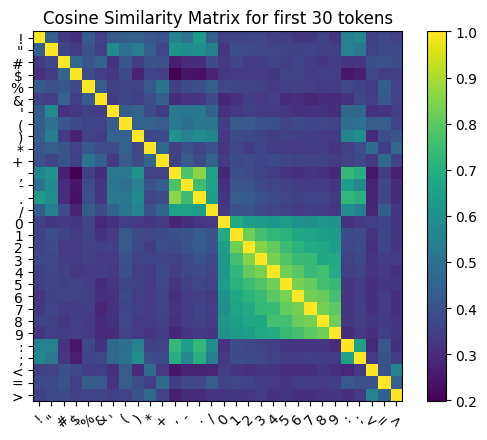

Difference: 0.0000000612
Difference with nn.functional: 0.0000000365


In [44]:
# Calculate the cosine similarity of the matrix manually
cosine_matrix_manual = np.zeros((30, 30))
emb_first_30_np = emb_first_30.detach().numpy()

for i in range(30):
    for j in range(30):
        num = emb_first_30_np[i] @ emb_first_30_np[j]
        den = np.linalg.norm(emb_first_30_np[i]) * np.linalg.norm(emb_first_30_np[j])
        cosine_matrix_manual[i, j] = num / den

# Visualize
plt.imshow(cosine_matrix_manual)
plt.colorbar()
ticklabels = [tokenizer.decode(i) for i in range(30)]
plt.xticks(np.arange(30), ticklabels, rotation=45)
plt.yticks(np.arange(30), ticklabels)
plt.title('Cosine Similarity Matrix for first 30 tokens')
plt.show()

print(f'Difference: {np.abs(cosine_matrix_manual - cosine_matrix_torch.detach().numpy()).mean():.10f}')
print(f'Difference with nn.functional: {np.abs(cosine_matrix_manual - cosine_matrix_nn.detach().numpy()).mean():.10f}')


tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


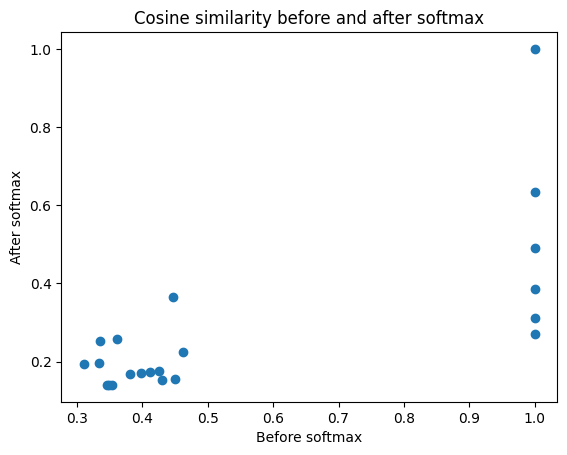

In [45]:
emb_first_6 = emb[:6, :]
T = emb_first_6.shape[0]

cs_torch = torch.cosine_similarity(
    emb_first_6.unsqueeze(1),
    emb_first_6.unsqueeze(0),
    dim=-1
    )

# Replace NaNs (from zero vectors) with a large negative finite value
cs_torch = torch.nan_to_num(cs_torch, nan=-1e9)

# Causal mask: mask future tokens (j > i)
future_mask = torch.triu(torch.ones(T, T, device=cs_torch.device), diagonal=1).bool()
cs_torch = cs_torch.masked_fill(future_mask, float('-inf'))

cs_softmax = torch.softmax(cs_torch, dim=1)
print(cs_softmax.sum(dim=1).detach())

plt.plot(cs_torch.flatten().detach().cpu(),
         cs_softmax.flatten().detach().cpu(), 'o')
plt.xlabel('Before softmax')
plt.ylabel('After softmax')
plt.title('Cosine similarity before and after softmax')
plt.show()


In [46]:
cs_softmax

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3651, 0.6349, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2519, 0.2584, 0.4897, 0.0000, 0.0000, 0.0000],
        [0.1930, 0.1975, 0.2248, 0.3847, 0.0000, 0.0000],
        [0.1756, 0.1710, 0.1734, 0.1680, 0.3121, 0.0000],
        [0.1413, 0.1403, 0.1556, 0.1406, 0.1525, 0.2697]],
       grad_fn=<SoftmaxBackward0>)

In [47]:
cs_torch

tensor([[1.0000,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4466, 1.0000,   -inf,   -inf,   -inf,   -inf],
        [0.3352, 0.3607, 1.0000,   -inf,   -inf,   -inf],
        [0.3105, 0.3334, 0.4627, 1.0000,   -inf,   -inf],
        [0.4248, 0.3983, 0.4124, 0.3807, 1.0000,   -inf],
        [0.3532, 0.3467, 0.4497, 0.3483, 0.4301, 1.0000]],
       grad_fn=<MaskedFillBackward0>)

In [48]:
rand_token_idx = torch.randint(tokenizer.vocab_size,(1,))
print(f'Token selected is: {tokenizer.decode(rand_token_idx)}')

# Get the embedding for the selected random token
rand_token_embedding = emb[rand_token_idx]

# Calculate cosine similarity with all other embeddings in the matrix
cs_randtoken = torch.cosine_similarity(x1=rand_token_embedding, x2=emb, dim=1)

top_cs, top_cs_idx = torch.topk(cs_randtoken, k=10)

print('\n'.join([f'Sc = {sc:.3f} with token "{tokenizer.decode(idx)}"' for sc, idx in zip(top_cs, top_cs_idx)]))


Token selected is:  gifted
Sc = 1.000 with token " gifted"
Sc = 0.586 with token " talented"
Sc = 0.529 with token " endowed"
Sc = 0.520 with token " bestowed"
Sc = 0.513 with token " gifts"
Sc = 0.513 with token " gift"
Sc = 0.487 with token " blessed"
Sc = 0.486 with token " entrusted"
Sc = 0.485 with token " Gift"
Sc = 0.478 with token "ifted"


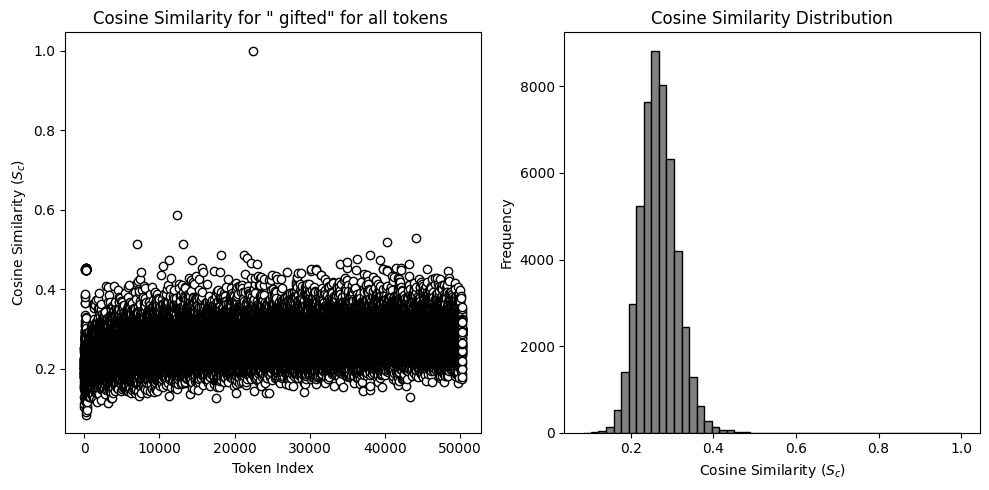

In [54]:
# Plot of costine similarities of all tokens with the selected word and distribution of the cosine_similarities

_, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(cs_randtoken.detach(),'o',markerfacecolor='w', markeredgecolor='k')
axs[0].set(xlabel='Token Index', ylabel='Cosine Similarity ($S_c$)', title=f'Cosine Similarity for "{tokenizer.decode(rand_token_idx)}" for all tokens ')

axs[1].hist(cs_randtoken.detach().numpy().ravel(), bins=50, edgecolor='k', color=(0.5,0.5,0.5))
axs[1].set(xlabel='Cosine Similarity ($S_c$)', ylabel='Frequency', title='Cosine Similarity Distribution')

plt.tight_layout()
plt.show()